Loaded 53,809 invoices from 4,920 customers
Date range: 2019-01-17 to 2025-12-28

Cohorts span from 2019-Q1 to 2025-Q4
Number of distinct cohorts: 28

Cohort size range: 53 – 299 customers
Total customers across all cohorts: 4,920

After truncation: 26 cohorts retained (dropped 2 incomplete cohorts)

Retention matrix shape: 26 cohorts × 21 follow-up quarters

VERIFICATION CHECKS

✅ Check 1 — Cohort sizes sum to total customers
   Sum of cohort sizes: 4,920
   Unique customers in data: 4,920

✅ Check 2 — No customer appears before their first invoice

✅ Check 3 — Spot-check cohort 2019-Q1 at Q+1
   Cohort size: 53 customers
   Active in 2019-Q2: 51 customers
   Manual retention: 96.23%
   Matrix retention: 96.23%

✅ Check 4 — No retention exceeds 100%
   Maximum retention value: 97.1%

✅ Check 5 — Average retention trends downward
   Avg retention at Q+1: 92.9%
   Avg retention at Q+21: 1.2%

✅ Check 6 — No single cohort dominates (largest is 6.1%)
   Largest cohort: 2024-Q4 (299 custom

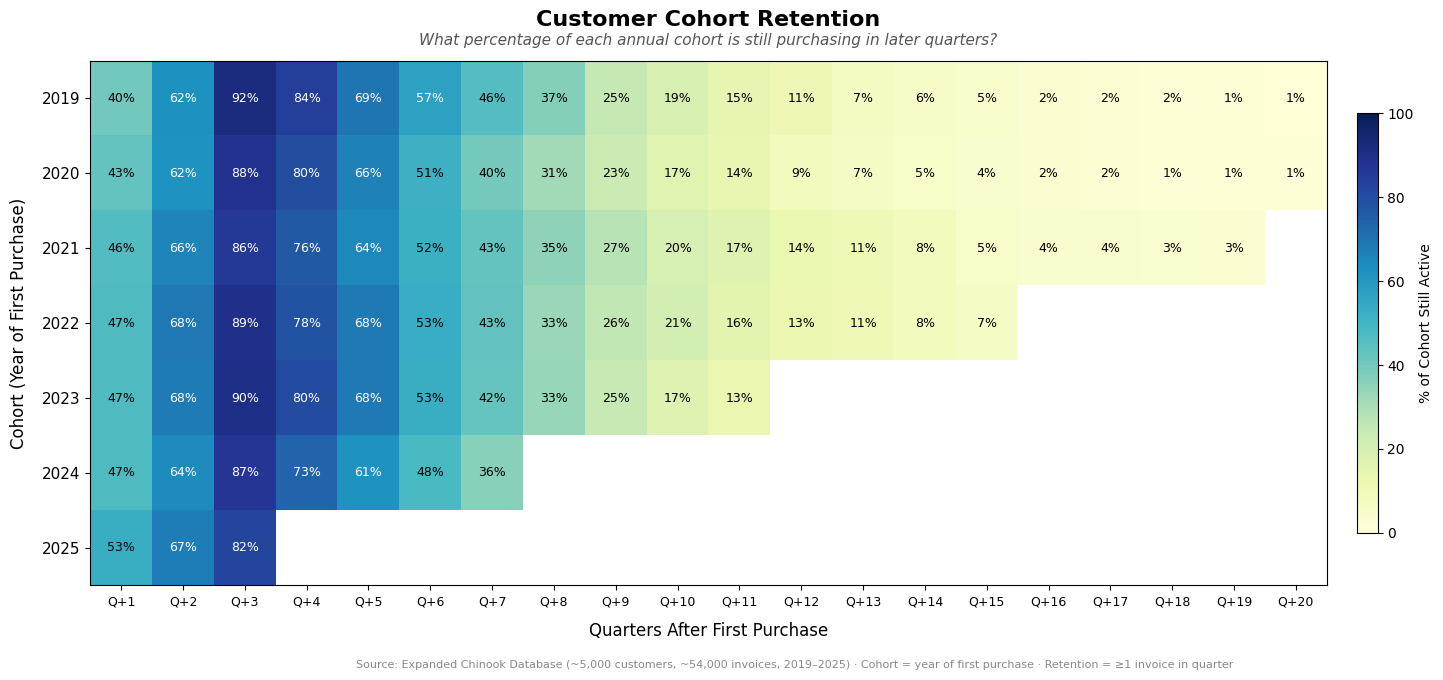


✅ Heatmap saved: part3_v2_cohort_retention_heatmap.png


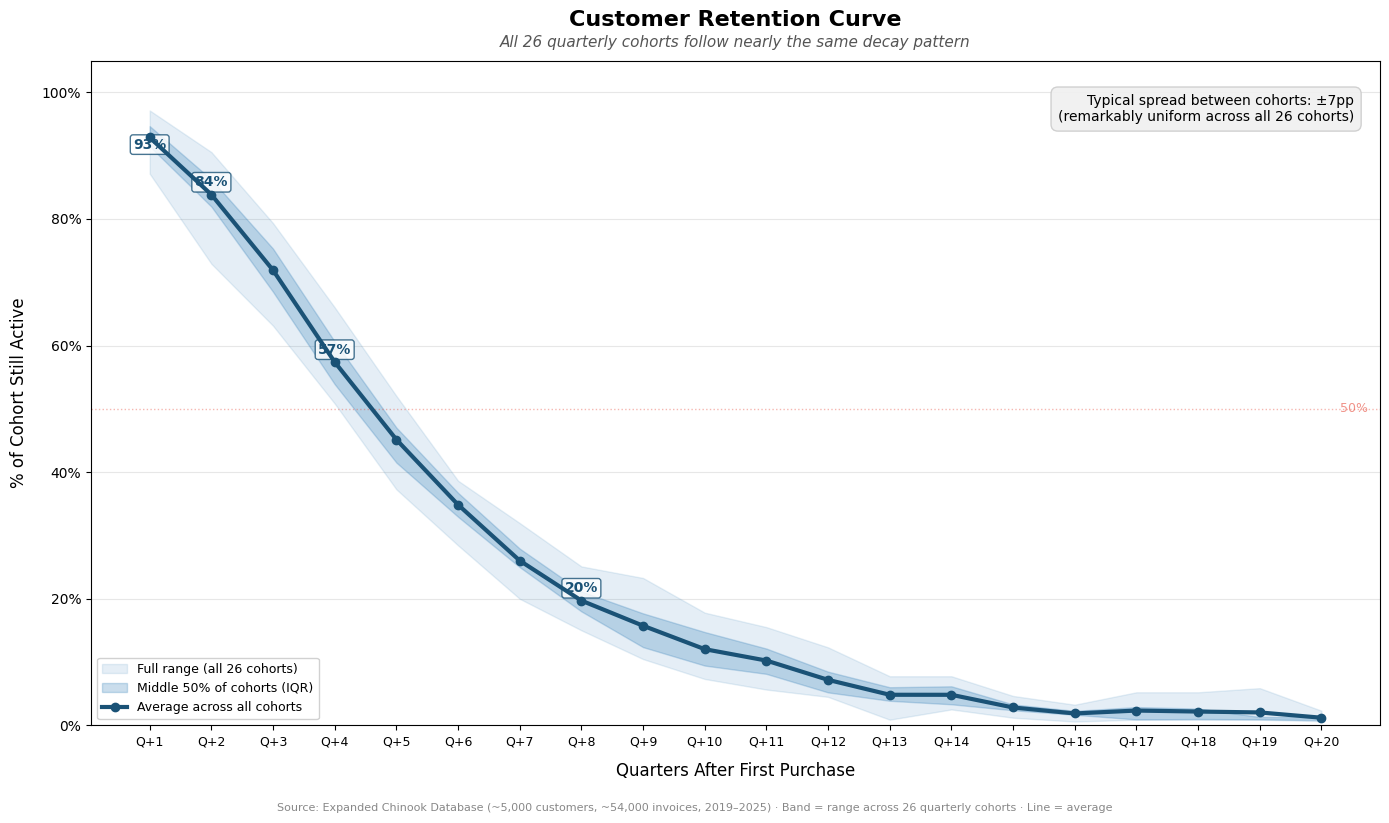


✅ Retention curve saved: part3_v2_cohort_retention_curve.png

DROP-OFF ANALYSIS — Quarter-over-Quarter Retention Loss

   Quarter   Drop (pp)   Retention   Cum. Lost
---------------------------------------------
   Q+1         -7.1pp      92.9%       7.1%
   Q+2         -9.0pp      83.9%      16.1%
   Q+3        -11.9pp      71.9%      28.1%
   Q+4        -14.5pp      57.4%      42.6%
   Q+5        -12.2pp      45.2%      54.8%
   Q+6        -10.3pp      34.9%      65.1%
   Q+7         -8.8pp      26.0%      74.0%
   Q+8         -6.3pp      19.7%      80.3%
   Q+9         -4.0pp      15.7%      84.3%
   Q+10        -3.7pp      12.0%      88.0%
   Q+11        -1.8pp      10.2%      89.8%
   Q+12        -3.0pp       7.2%      92.8%
   Q+13        -2.4pp       4.8%      95.2%
   Q+14        -0.0pp       4.8%      95.2%
   Q+15        -2.0pp       2.8%      97.2%
   Q+16        -0.9pp       1.9%      98.1%

⚠️  Steepest single-quarter drop: Q+4 (-14.5pp)
   Curve stabilizes around Q+8 (dr

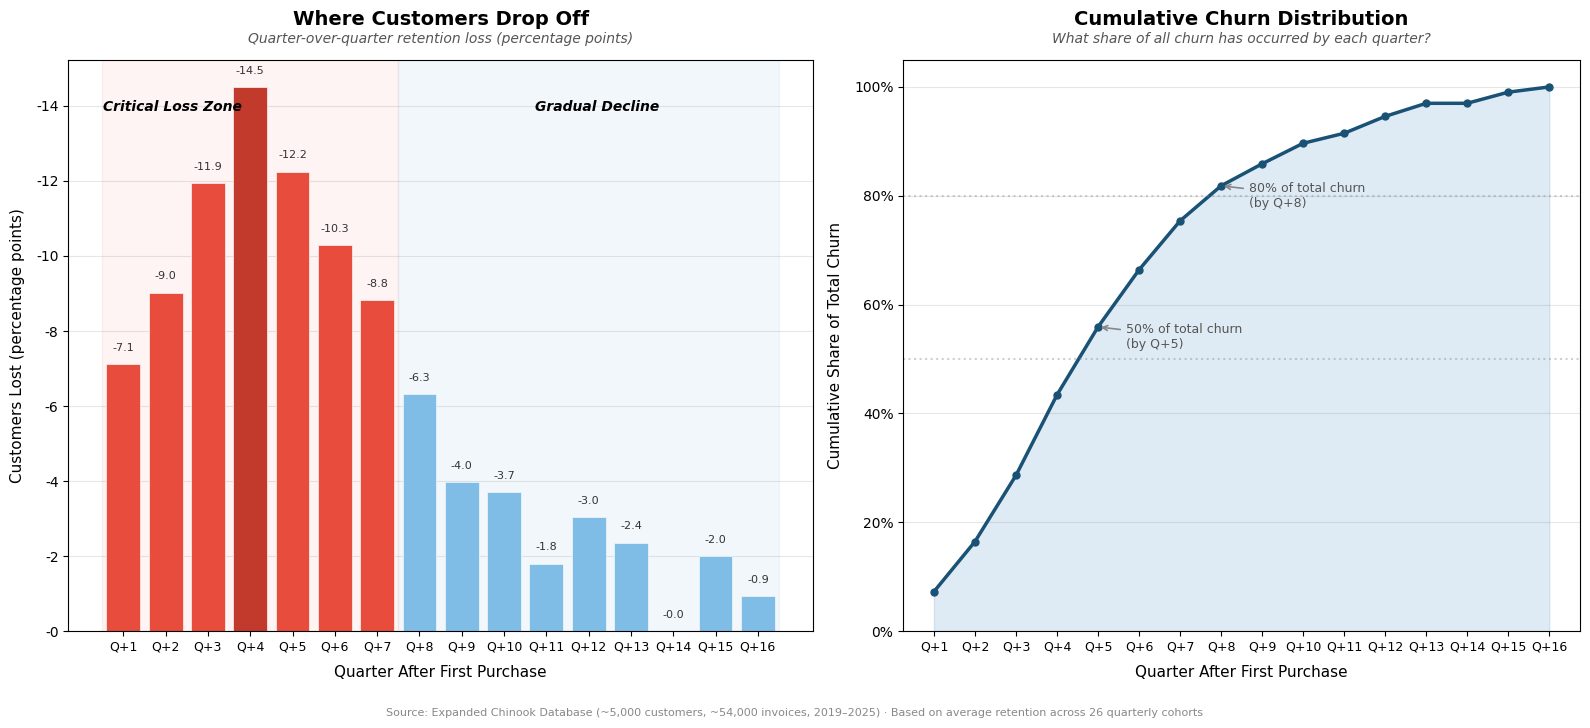


✅ Drop-off analysis saved: part3_v2_dropoff_analysis.png

✅ Data exported: part3_v2_retention_matrix.csv, part3_v2_retention_matrix_annual.csv

END OF PART 3 (V2) — COHORT RETENTION ANALYSIS


In [8]:
#!/usr/bin/env python3
"""
Part 3 — Cohort Retention Analysis
Case Study 1: Is the Purchase Pattern Real?

Do customers actually stick around? This analysis groups customers by the
quarter they first purchased, then tracks what percentage of each cohort
is still making purchases in subsequent quarters.

Parts 1 and 2 looked at *timing*. Part 3 looks at the *people*.
"""

# =============================================================================
# SETUP & DATA PULL
# =============================================================================
# Standard libraries — same stack as Parts 1 and 2
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# --- Connect to the expanded Chinook database ---
DB_PATH = "chinook_expanded.db"
conn = sqlite3.connect(DB_PATH)

# Pull every invoice — we need CustomerId and InvoiceDate to build cohorts
# Sorting by customer then date ensures chronological order within each customer
invoices = pd.read_sql("""
    SELECT CustomerId, InvoiceDate, InvoiceId, Total
    FROM Invoice
    ORDER BY CustomerId, InvoiceDate
""", conn)

conn.close()

# Parse dates — sqlite stores these as strings
invoices['InvoiceDate'] = pd.to_datetime(invoices['InvoiceDate'])

print(f"Loaded {len(invoices):,} invoices from {invoices['CustomerId'].nunique():,} customers")
print(f"Date range: {invoices['InvoiceDate'].min().date()} to {invoices['InvoiceDate'].max().date()}")


# =============================================================================
# STEP 1: ASSIGN EACH CUSTOMER TO A COHORT
# =============================================================================
# A customer's cohort = the calendar quarter of their FIRST purchase.
# We derive this from the invoice data itself — no separate signup table.

# Find each customer's first invoice date
first_purchase = (invoices
    .groupby('CustomerId')['InvoiceDate']
    .min()
    .reset_index()
    .rename(columns={'InvoiceDate': 'FirstPurchaseDate'}))

# Convert first purchase date to a quarter label (e.g., "2020-Q1")
# Using PeriodIndex gives clean quarter labels without manual string formatting
first_purchase['CohortQuarter'] = (
    pd.PeriodIndex(first_purchase['FirstPurchaseDate'], freq='Q')
    .strftime('%Y-Q%q'))

# Merge cohort assignment back to every invoice
# Now each row knows: this invoice belongs to a customer from cohort X
invoices = invoices.merge(first_purchase[['CustomerId', 'CohortQuarter', 'FirstPurchaseDate']],
                          on='CustomerId', how='left')

# Also tag each invoice with the calendar quarter it occurred in
invoices['InvoiceQuarter'] = (
    pd.PeriodIndex(invoices['InvoiceDate'], freq='Q')
    .strftime('%Y-Q%q'))

print(f"\nCohorts span from {first_purchase['CohortQuarter'].min()} "
      f"to {first_purchase['CohortQuarter'].max()}")
print(f"Number of distinct cohorts: {first_purchase['CohortQuarter'].nunique()}")


# =============================================================================
# STEP 2: BUILD THE RETENTION MATRIX
# =============================================================================
# For each cohort, calculate what % of original customers were active in each
# subsequent quarter. "Active" = at least one invoice in that quarter.

# Get cohort sizes — how many customers in each cohort
cohort_sizes = (first_purchase
    .groupby('CohortQuarter')['CustomerId']
    .nunique()
    .rename('CohortSize'))

print(f"\nCohort size range: {cohort_sizes.min()} – {cohort_sizes.max()} customers")
print(f"Total customers across all cohorts: {cohort_sizes.sum():,}")

# For each cohort × quarter combination, count unique active customers
# This is the raw activity matrix before converting to percentages
cohort_activity = (invoices
    .groupby(['CohortQuarter', 'InvoiceQuarter'])['CustomerId']
    .nunique()
    .reset_index()
    .rename(columns={'CustomerId': 'ActiveCustomers'}))

# We need to convert calendar quarters to "quarters since first purchase"
# so cohorts are comparable on the same timeline

# Build a lookup: all unique quarters in chronological order
all_quarters_sorted = sorted(invoices['InvoiceQuarter'].unique())
quarter_to_index = {q: i for i, q in enumerate(all_quarters_sorted)}

# Calculate "quarters since cohort start" for each row
cohort_activity['CohortQuarterIndex'] = cohort_activity['CohortQuarter'].map(quarter_to_index)
cohort_activity['InvoiceQuarterIndex'] = cohort_activity['InvoiceQuarter'].map(quarter_to_index)
cohort_activity['QuartersSinceFirst'] = (
    cohort_activity['InvoiceQuarterIndex'] - cohort_activity['CohortQuarterIndex'])

# Merge in cohort sizes to calculate retention percentages
cohort_activity = cohort_activity.merge(
    cohort_sizes.reset_index(), on='CohortQuarter', how='left')

cohort_activity['RetentionPct'] = (
    cohort_activity['ActiveCustomers'] / cohort_activity['CohortSize'] * 100)

# --- Exclude Quarter 0 (the cohort's signup quarter — always 100%) ---
# It adds no information and compresses the interesting part of the chart
cohort_activity = cohort_activity[cohort_activity['QuartersSinceFirst'] > 0].copy()

# --- Truncate incomplete cohorts ---
# A cohort needs at least 2 full quarters of post-signup observation to be
# meaningful. Cohorts formed too recently distort the right edge of the heatmap.
last_data_quarter = all_quarters_sorted[-1]
last_quarter_index = quarter_to_index[last_data_quarter]

# For each cohort, calculate how many full quarters of observation they have
# Use a simple dict comprehension — each cohort has exactly one start quarter
unique_cohorts = sorted(first_purchase['CohortQuarter'].unique())
observation_quarters = {
    cohort: last_quarter_index - quarter_to_index[cohort]
    for cohort in unique_cohorts
}

# Keep only cohorts with at least 2 quarters of post-signup data
valid_cohorts = [c for c, obs in observation_quarters.items() if obs >= 2]
cohort_activity = cohort_activity[cohort_activity['CohortQuarter'].isin(valid_cohorts)].copy()

print(f"\nAfter truncation: {len(valid_cohorts)} cohorts retained "
      f"(dropped {cohort_sizes.index.nunique() - len(valid_cohorts)} incomplete cohorts)")

# --- Pivot into retention matrix ---
# Rows = cohort quarters, Columns = quarters since first purchase, Values = retention %
retention_matrix = cohort_activity.pivot_table(
    index='CohortQuarter',
    columns='QuartersSinceFirst',
    values='RetentionPct')

# Sort rows chronologically and columns numerically
retention_matrix = retention_matrix.sort_index()
retention_matrix = retention_matrix[sorted(retention_matrix.columns)]

print(f"\nRetention matrix shape: {retention_matrix.shape[0]} cohorts × "
      f"{retention_matrix.shape[1]} follow-up quarters")


# =============================================================================
# STEP 3: VERIFICATION CHECKS
# =============================================================================
# Run these BEFORE visualizing — if the numbers are wrong, the charts are
# meaningless. (Lesson from Part 1: verify first, then evaluate.)

print("\n" + "="*60)
print("VERIFICATION CHECKS")
print("="*60)

# --- Check 1: Cohort sizes sum to total unique customers ---
total_from_cohorts = cohort_sizes.sum()
total_unique_customers = invoices['CustomerId'].nunique()
check1_pass = total_from_cohorts == total_unique_customers
print(f"\n✅ Check 1 — Cohort sizes sum to total customers" if check1_pass
      else f"\n❌ Check 1 — MISMATCH")
print(f"   Sum of cohort sizes: {total_from_cohorts:,}")
print(f"   Unique customers in data: {total_unique_customers:,}")

# --- Check 2: No customer assigned to a cohort before their first invoice ---
# This catches join errors where a customer's cohort quarter is AFTER their
# earliest actual purchase (would mean the cohort derivation is wrong)
cohort_check = invoices.groupby('CustomerId').agg(
    earliest_invoice=('InvoiceDate', 'min'),
    assigned_first=('FirstPurchaseDate', 'first'))
mismatches = cohort_check[cohort_check['earliest_invoice'] != cohort_check['assigned_first']]
check2_pass = len(mismatches) == 0
print(f"\n✅ Check 2 — No customer appears before their first invoice" if check2_pass
      else f"\n❌ Check 2 — {len(mismatches)} customers have mismatched cohort assignments")

# --- Check 3: Spot-check one cohort's retention by hand ---
# Pick the cohort with the most observation history for the clearest test
spot_cohort = valid_cohorts[0]  # Earliest cohort = most history
spot_cohort_customers = first_purchase[
    first_purchase['CohortQuarter'] == spot_cohort]['CustomerId'].tolist()
spot_cohort_size = len(spot_cohort_customers)

# Manually count: how many of these customers had an invoice in quarter+1?
spot_target_quarter = all_quarters_sorted[quarter_to_index[spot_cohort] + 1]
manual_count = invoices[
    (invoices['CustomerId'].isin(spot_cohort_customers)) &
    (invoices['InvoiceQuarter'] == spot_target_quarter)
]['CustomerId'].nunique()
manual_retention = manual_count / spot_cohort_size * 100

# Compare to what the matrix says
matrix_retention = retention_matrix.loc[spot_cohort, 1]  # Quarter offset 1
check3_pass = abs(manual_retention - matrix_retention) < 0.01
print(f"\n✅ Check 3 — Spot-check cohort {spot_cohort} at Q+1" if check3_pass
      else f"\n❌ Check 3 — Spot-check FAILED for {spot_cohort}")
print(f"   Cohort size: {spot_cohort_size} customers")
print(f"   Active in {spot_target_quarter}: {manual_count} customers")
print(f"   Manual retention: {manual_retention:.2f}%")
print(f"   Matrix retention: {matrix_retention:.2f}%")

# --- Check 4: No retention value exceeds 100% ---
max_retention = retention_matrix.max().max()
check4_pass = max_retention <= 100.0
print(f"\n✅ Check 4 — No retention exceeds 100%" if check4_pass
      else f"\n❌ Check 4 — Max retention is {max_retention:.1f}% (impossible)")
print(f"   Maximum retention value: {max_retention:.1f}%")

# --- Check 5: Retention generally declines over time (sanity check) ---
# Not strictly required (reactivation is possible), but if Q+8 retention is
# HIGHER than Q+1 for most cohorts, something is likely wrong
col_means = retention_matrix.mean()
if len(col_means) >= 2:
    q1_mean = col_means.iloc[0]
    last_mean = col_means.iloc[-1]
    check5_pass = q1_mean > last_mean
    print(f"\n✅ Check 5 — Average retention trends downward" if check5_pass
          else f"\n⚠️  Check 5 — Average retention does NOT trend down (unusual)")
    print(f"   Avg retention at Q+1: {q1_mean:.1f}%")
    print(f"   Avg retention at Q+{int(col_means.index[-1])}: {last_mean:.1f}%")

all_passed = all([check1_pass, check2_pass, check3_pass, check4_pass])

# --- Check 6: Cohort size distribution — is one cohort dominating the average? ---
# If a single cohort holds 40%+ of all customers, the "average retention curve"
# is really just that cohort's curve. The heatmap would still be correct, but
# the marketing director would be drawing conclusions from one wave of signups,
# not a cross-cohort pattern. This doesn't fail the math — it fails the framing.
cohort_size_pcts = cohort_sizes / cohort_sizes.sum() * 100
largest_cohort = cohort_size_pcts.idxmax()
largest_cohort_pct = cohort_size_pcts.max()
check6_pass = largest_cohort_pct < 25  # No single cohort > 25% of customer base
print(f"\n✅ Check 6 — No single cohort dominates (largest is {largest_cohort_pct:.1f}%)" if check6_pass
      else f"\n⚠️  Check 6 — Cohort {largest_cohort} holds {largest_cohort_pct:.1f}% of all customers")
print(f"   Largest cohort: {largest_cohort} ({cohort_sizes[largest_cohort]:,} customers, {largest_cohort_pct:.1f}%)")
print(f"   Smallest cohort: {cohort_size_pcts.idxmin()} ({cohort_sizes[cohort_size_pcts.idxmin()]:,} customers, {cohort_size_pcts.min():.1f}%)")
if not check6_pass:
    print(f"   → The 'average' curve is heavily weighted by {largest_cohort}. "
          f"Interpret with caution or weight cohorts equally.")

# --- Check 7: Quarter-boundary accuracy ---
# A customer who purchased on March 31 and April 1 should be in different quarters.
# This check catches any off-by-one in the quarter assignment logic by testing
# known boundary dates. If the database has invoices near quarter boundaries,
# we verify they land in the correct quarter.
boundary_tests = [
    ('2020-01-01', '2020-Q1'),
    ('2020-03-31', '2020-Q1'),
    ('2020-04-01', '2020-Q2'),
    ('2020-06-30', '2020-Q2'),
    ('2020-07-01', '2020-Q3'),
    ('2020-12-31', '2020-Q4'),
]
boundary_failures = []
for date_str, expected_q in boundary_tests:
    actual_q = pd.Period(date_str, freq='Q').strftime('%Y-Q%q')
    if actual_q != expected_q:
        boundary_failures.append((date_str, expected_q, actual_q))
check7_pass = len(boundary_failures) == 0
print(f"\n✅ Check 7 — Quarter boundary logic correct (6/6 test dates)" if check7_pass
      else f"\n❌ Check 7 — Quarter boundary ERRORS: {boundary_failures}")

# --- Check 8: Second spot-check — different cohort, later quarter ---
# Check 3 tested the earliest cohort at Q+1. This tests a MID-RANGE cohort
# at a LATER offset (Q+4). Catches errors that only appear with larger offsets
# (e.g., off-by-one in QuartersSinceFirst, or pivot_table silently aggregating wrong).
mid_idx = len(valid_cohorts) // 2
spot_cohort_2 = valid_cohorts[mid_idx]
spot2_customers = first_purchase[
    first_purchase['CohortQuarter'] == spot_cohort_2]['CustomerId'].tolist()
spot2_size = len(spot2_customers)

# Target Q+4 if available, otherwise the latest offset available for this cohort
spot2_offset = min(4, int(retention_matrix.loc[spot_cohort_2].dropna().index.max()))
spot2_target_q = all_quarters_sorted[quarter_to_index[spot_cohort_2] + spot2_offset]

manual_count_2 = invoices[
    (invoices['CustomerId'].isin(spot2_customers)) &
    (invoices['InvoiceQuarter'] == spot2_target_q)
]['CustomerId'].nunique()
manual_retention_2 = manual_count_2 / spot2_size * 100
matrix_retention_2 = retention_matrix.loc[spot_cohort_2, spot2_offset]

check8_pass = abs(manual_retention_2 - matrix_retention_2) < 0.01
print(f"\n✅ Check 8 — Second spot-check: cohort {spot_cohort_2} at Q+{spot2_offset}" if check8_pass
      else f"\n❌ Check 8 — Second spot-check FAILED for {spot_cohort_2} at Q+{spot2_offset}")
print(f"   Cohort size: {spot2_size} customers")
print(f"   Active in {spot2_target_q}: {manual_count_2} customers")
print(f"   Manual retention: {manual_retention_2:.2f}%")
print(f"   Matrix retention: {matrix_retention_2:.2f}%")

# --- Check 9: Truncation logic validation ---
# Verify that every EXCLUDED cohort truly has <2 quarters of observation,
# and every INCLUDED cohort truly has >=2. Catches logic inversions or
# off-by-one in the truncation threshold.
all_cohorts_set = set(unique_cohorts)
valid_set = set(valid_cohorts)
excluded_set = all_cohorts_set - valid_set

trunc_failures = []
for cohort in valid_set:
    obs = observation_quarters[cohort]
    if obs < 2:
        trunc_failures.append((cohort, obs, 'included but has <2 quarters'))
for cohort in excluded_set:
    obs = observation_quarters[cohort]
    if obs >= 2:
        trunc_failures.append((cohort, obs, 'excluded but has >=2 quarters'))

check9_pass = len(trunc_failures) == 0
print(f"\n✅ Check 9 — Truncation logic correct ({len(valid_set)} included, {len(excluded_set)} excluded)" if check9_pass
      else f"\n❌ Check 9 — Truncation errors: {trunc_failures}")
if excluded_set:
    excluded_list = sorted(excluded_set)
    print(f"   Excluded cohorts: {', '.join(excluded_list)}")
    print(f"   Reason: fewer than 2 full quarters of post-signup observation")

all_passed = all([check1_pass, check2_pass, check3_pass, check4_pass,
                  check6_pass, check7_pass, check8_pass, check9_pass])
# Check 5 is a soft warning (⚠️), not a hard fail — reactivation patterns
# could legitimately cause non-monotonic retention in some datasets
print(f"\n{'='*60}")
print(f"{'All checks passed. Proceeding to visualization.' if all_passed else 'ISSUES DETECTED — review before visualizing.'}")
print(f"{'='*60}")


# =============================================================================
# STEP 4: SUMMARY STATISTICS
# =============================================================================
# Print key retention metrics before the charts — gives the marketing director
# the numbers they need for a budget conversation

print("\n" + "="*60)
print("RETENTION SUMMARY")
print("="*60)

# Average retention at each quarter mark (across all cohorts)
avg_retention = retention_matrix.mean()
print("\nAverage retention by quarters after first purchase:")
for q in sorted(avg_retention.index[:12]):
    bar = "█" * int(avg_retention[q] / 2)  # Simple text bar for quick scan
    print(f"   Q+{int(q):>2d}: {avg_retention[q]:>5.1f}%  {bar}")
if len(avg_retention) > 12:
    print(f"   ...({len(avg_retention) - 12} more quarters)")

# The "critical drop" — where does retention fall below 50%?
below_50 = avg_retention[avg_retention < 50]
if len(below_50) > 0:
    critical_quarter = int(below_50.index[0])
    print(f"\n⚠️  Average retention drops below 50% at Q+{critical_quarter} "
          f"({avg_retention[critical_quarter]:.1f}%)")
else:
    print(f"\n   Retention stays above 50% across all observed quarters")

# Compare oldest vs newest valid cohorts
oldest_cohort = valid_cohorts[0]
newest_cohort = valid_cohorts[-1]
if 1 in retention_matrix.columns:
    oldest_q1 = retention_matrix.loc[oldest_cohort, 1]
    newest_q1 = retention_matrix.loc[newest_cohort, 1]
    print(f"\nFirst-quarter retention comparison:")
    print(f"   Oldest cohort ({oldest_cohort}): {oldest_q1:.1f}%")
    print(f"   Newest cohort ({newest_cohort}): {newest_q1:.1f}%")
    diff = newest_q1 - oldest_q1
    direction = "higher" if diff > 0 else "lower"
    print(f"   Difference: {abs(diff):.1f}pp {direction} for newer cohort")


# =============================================================================
# STEP 5: HEATMAP — Annualized Cohorts (V2)
# =============================================================================
# V1 had 26 quarterly rows — visual overload. The key finding was that all
# cohorts follow nearly the same curve. Grouping by YEAR instead of quarter
# preserves that story with ~7 rows instead of 26, and each row has more
# customers behind it (more stable percentages, less noise).

# --- Build annualized retention matrix ---
# Assign each customer to a YEAR cohort based on their first purchase
first_purchase['CohortYear'] = first_purchase['FirstPurchaseDate'].dt.year
invoices = invoices.merge(first_purchase[['CustomerId', 'CohortYear']],
                          on='CustomerId', how='left')

# Cohort sizes by year
year_cohort_sizes = (first_purchase
    .groupby('CohortYear')['CustomerId']
    .nunique()
    .rename('CohortSize'))

# Activity by year cohort × invoice quarter offset
# We still measure retention in QUARTERS (not years) — that's where the
# actionable granularity lives. We just group the cohorts more coarsely.
year_activity = (invoices
    .groupby(['CohortYear', 'InvoiceQuarter'])['CustomerId']
    .nunique()
    .reset_index()
    .rename(columns={'CustomerId': 'ActiveCustomers'}))

# For year cohorts, "quarters since first" is measured from Q1 of the cohort year
# (approximation — some customers joined in Q2/Q3/Q4, so Q+1 retention for a
# year cohort will be slightly higher than for a Q1-only cohort. This is a
# deliberate trade-off: cleaner rows vs. slightly less precise offsets.)
year_activity['CohortStartIndex'] = year_activity['CohortYear'].apply(
    lambda y: quarter_to_index.get(f'{y}-Q1', 0))
year_activity['InvoiceQuarterIndex'] = year_activity['InvoiceQuarter'].map(quarter_to_index)
year_activity['QuartersSinceFirst'] = (
    year_activity['InvoiceQuarterIndex'] - year_activity['CohortStartIndex'])

# Drop Q0 and negative offsets (customers who joined mid-year will have
# activity in the same quarter as their year's Q1 — that's still "Q0")
year_activity = year_activity[year_activity['QuartersSinceFirst'] > 0].copy()

# Merge sizes and calculate retention
year_activity = year_activity.merge(
    year_cohort_sizes.reset_index(), on='CohortYear', how='left')
year_activity['RetentionPct'] = (
    year_activity['ActiveCustomers'] / year_activity['CohortSize'] * 100)

# Pivot into year-based retention matrix
year_retention_matrix = year_activity.pivot_table(
    index='CohortYear',
    columns='QuartersSinceFirst',
    values='RetentionPct')
year_retention_matrix = year_retention_matrix.sort_index()
year_retention_matrix = year_retention_matrix[sorted(year_retention_matrix.columns)]

# Truncate: drop last year if it has <2 quarters, cap columns at 20
last_year = year_retention_matrix.index[-1]
non_null_count = year_retention_matrix.loc[last_year].notna().sum()
if non_null_count < 2:
    year_retention_matrix = year_retention_matrix.iloc[:-1]

max_display_q = min(20, year_retention_matrix.shape[1])
year_display = year_retention_matrix.iloc[:, :max_display_q]

print(f"\nAnnualized heatmap: {year_display.shape[0]} year-cohorts × "
      f"{year_display.shape[1]} follow-up quarters")

# --- Plot the heatmap ---
fig, ax = plt.subplots(figsize=(16, max(4, len(year_display) * 0.8 + 1)))

cmap = plt.cm.YlGnBu
im = ax.imshow(year_display.values, cmap=cmap, aspect='auto', vmin=0, vmax=100)

# Annotate each cell
for i in range(year_display.shape[0]):
    for j in range(year_display.shape[1]):
        val = year_display.iloc[i, j]
        if pd.notna(val):
            text_color = 'white' if val > 55 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=9, color=text_color, fontweight='medium')

# Axis labels
ax.set_xticks(range(max_display_q))
ax.set_xticklabels([f'Q+{int(c)}' for c in year_display.columns], fontsize=9)
ax.set_yticks(range(len(year_display)))
ax.set_yticklabels([str(y) for y in year_display.index], fontsize=11, fontweight='medium')

ax.set_xlabel('Quarters After First Purchase', fontsize=12, labelpad=10)
ax.set_ylabel('Cohort (Year of First Purchase)', fontsize=12, labelpad=10)

# Title hierarchy — consistent with Parts 1 and 2
ax.set_title('Customer Cohort Retention',
             fontsize=16, fontweight='bold', pad=25)
ax.text(0.5, 1.03,
        'What percentage of each annual cohort is still purchasing in later quarters?',
        transform=ax.transAxes, ha='center', fontsize=11, color='#555555',
        style='italic')

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('% of Cohort Still Active', fontsize=10)

# Source note
fig.text(0.5, -0.02,
         'Source: Expanded Chinook Database (~5,000 customers, ~54,000 invoices, 2019–2025) · '
         'Cohort = year of first purchase · Retention = ≥1 invoice in quarter',
         ha='center', fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig('part3_v2_cohort_retention_heatmap.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("\n✅ Heatmap saved: part3_v2_cohort_retention_heatmap.png")


# =============================================================================
# STEP 6: RETENTION CURVE — Band + Average (V2)
# =============================================================================
# V1 plotted 26 individual lines — spaghetti. The key insight is that all
# cohorts behave almost identically. V2 makes that UNIFORMITY the visual
# focal point: a shaded min/max band showing the full range of cohort behavior,
# with the average curve drawn bold on top. If the band is narrow, the story
# tells itself: it doesn't matter when customers joined — they all churn
# at the same rate.

fig, ax = plt.subplots(figsize=(14, 8))

# Use the QUARTERLY retention matrix (not annualized) for the band —
# 26 cohorts give a more honest range than 7 year-level aggregates
max_curve_q = min(20, retention_matrix.shape[1])
curve_matrix = retention_matrix.iloc[:, :max_curve_q]

# Calculate band statistics at each quarter offset
quarters = sorted(curve_matrix.columns)
avg_vals = []
min_vals = []
max_vals = []
p25_vals = []
p75_vals = []

for q in quarters:
    col = curve_matrix[q].dropna()
    if len(col) >= 3:  # Need enough cohorts for a meaningful range
        avg_vals.append(col.mean())
        min_vals.append(col.min())
        max_vals.append(col.max())
        p25_vals.append(col.quantile(0.25))
        p75_vals.append(col.quantile(0.75))
    else:
        avg_vals.append(np.nan)
        min_vals.append(np.nan)
        max_vals.append(np.nan)
        p25_vals.append(np.nan)
        p75_vals.append(np.nan)

quarters_arr = np.array(quarters)
avg_arr = np.array(avg_vals)
min_arr = np.array(min_vals)
max_arr = np.array(max_vals)
p25_arr = np.array(p25_vals)
p75_arr = np.array(p75_vals)

# Mask NaNs for clean plotting
valid_mask = ~np.isnan(avg_arr)
q_valid = quarters_arr[valid_mask]
avg_valid = avg_arr[valid_mask]
min_valid = min_arr[valid_mask]
max_valid = max_arr[valid_mask]
p25_valid = p25_arr[valid_mask]
p75_valid = p75_arr[valid_mask]

# --- Outer band: full min-max range across all 26 cohorts ---
ax.fill_between(q_valid, min_valid, max_valid,
                alpha=0.12, color='#2C7BB6', label='Full range (all 26 cohorts)')

# --- Inner band: interquartile range (P25–P75) ---
# This is where "most" cohorts fall — tighter band = more uniformity
ax.fill_between(q_valid, p25_valid, p75_valid,
                alpha=0.25, color='#2C7BB6', label='Middle 50% of cohorts (IQR)')

# --- Average curve: bold, the planning line ---
ax.plot(q_valid, avg_valid,
        linewidth=3, color='#1a5276', marker='o', markersize=6,
        label='Average across all cohorts', zorder=10)

# --- Annotate key retention values directly on the curve ---
# A marketing director needs specific numbers, not just a shape
annotation_quarters = [1, 2, 4, 8]  # Q+1, Q+2, Q+4, Q+8 — the decision points
for aq in annotation_quarters:
    if aq in q_valid:
        idx = list(q_valid).index(aq)
        val = avg_valid[idx]
        # Alternate label positions to avoid overlaps
        offset_y = 6 if aq % 2 == 0 else -8
        ax.annotate(f'{val:.0f}%',
                    xy=(aq, val), xytext=(0, offset_y),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    color='#1a5276', ha='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              edgecolor='#1a5276', alpha=0.8))

# --- Spread annotation: how tight is the band? ---
# This quantifies the key finding: "all cohorts behave the same"
if len(q_valid) >= 2:
    typical_spread = np.mean(max_valid[:8] - min_valid[:8])
    ax.text(0.98, 0.95,
            f'Typical spread between cohorts: ±{typical_spread/2:.0f}pp\n'
            f'(remarkably uniform across all 26 cohorts)',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0',
                      edgecolor='#cccccc', alpha=0.9))

# --- 50% threshold line ---
ax.axhline(y=50, color='#E74C3C', linestyle=':', alpha=0.4, linewidth=1)
ax.text(q_valid[-1] + 0.3, 50, '50%', fontsize=9, color='#E74C3C',
        va='center', alpha=0.6)

# --- Axis formatting ---
ax.set_xlabel('Quarters After First Purchase', fontsize=12, labelpad=10)
ax.set_ylabel('% of Cohort Still Active', fontsize=12, labelpad=10)
ax.set_xticks(range(1, max_curve_q + 1))
ax.set_xticklabels([f'Q+{i}' for i in range(1, max_curve_q + 1)], fontsize=9)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(axis='y', alpha=0.3, linestyle='-')
ax.set_axisbelow(True)

# Title hierarchy
ax.set_title('Customer Retention Curve',
             fontsize=16, fontweight='bold', pad=25)
ax.text(0.5, 1.02,
        'All 26 quarterly cohorts follow nearly the same decay pattern',
        transform=ax.transAxes, ha='center', fontsize=11, color='#555555',
        style='italic')

# Legend — inside plot, lower-left where the data isn't
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

# Source note
fig.text(0.5, -0.02,
         'Source: Expanded Chinook Database (~5,000 customers, ~54,000 invoices, 2019–2025) · '
         'Band = range across 26 quarterly cohorts · Line = average',
         ha='center', fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig('part3_v2_cohort_retention_curve.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("\n✅ Retention curve saved: part3_v2_cohort_retention_curve.png")


# =============================================================================
# STEP 7: DROP-OFF ANALYSIS — Where Is the Steepest Loss? (V2 — New)
# =============================================================================
# The retention curve shows WHERE customers end up. This analysis shows
# WHERE the losses happen — quarter by quarter. If 40% of all churn happens
# between Q+0 and Q+1, that's a fundamentally different problem (and a
# different campaign) than if losses are spread evenly across the first 8
# quarters. This is the intervention window analysis.

# Calculate quarter-over-quarter retention change (in percentage points)
# Using the average curve — since all cohorts behave similarly, the average
# is representative (verified by the narrow band in Step 6)

# Start from Q+0 = 100% to capture the first drop
full_avg = pd.Series({0: 100.0})
for q in sorted(avg_retention.index):
    full_avg[q] = avg_retention[q]
full_avg = full_avg.sort_index()

# Quarter-over-quarter drops
qoq_drop = full_avg.diff()  # Negative values = customers lost
qoq_drop = qoq_drop.dropna()

# Cap at a reasonable display range
max_dropoff_q = min(16, len(qoq_drop))
drop_quarters = sorted(qoq_drop.index[:max_dropoff_q])
drop_values = [qoq_drop[q] for q in drop_quarters]

print("\n" + "="*60)
print("DROP-OFF ANALYSIS — Quarter-over-Quarter Retention Loss")
print("="*60)
print(f"\n{'Quarter':>10s}  {'Drop (pp)':>10s}  {'Retention':>10s}  {'Cum. Lost':>10s}")
print("-" * 45)
for q in drop_quarters:
    ret = full_avg[q]
    lost = 100 - ret
    print(f"   Q+{int(q):<4d}   {qoq_drop[q]:>+7.1f}pp    {ret:>6.1f}%    {lost:>6.1f}%")

# Find the steepest single drop
steepest_q = min(drop_quarters, key=lambda q: qoq_drop[q])
steepest_val = qoq_drop[steepest_q]
print(f"\n⚠️  Steepest single-quarter drop: Q+{int(steepest_q)} "
      f"({steepest_val:+.1f}pp)")

# Find where the curve stabilizes — first quarter where drop is less than
# half the steepest drop (the "elbow")
stabilization_threshold = abs(steepest_val) / 2
for q in drop_quarters:
    if abs(qoq_drop[q]) < stabilization_threshold and q > steepest_q:
        print(f"   Curve stabilizes around Q+{int(q)} "
              f"(drop narrows to {qoq_drop[q]:+.1f}pp per quarter)")
        stabilization_q = int(q)
        break
else:
    stabilization_q = None
    print("   No clear stabilization point within observed range")

# --- Plot the drop-off bar chart ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                 gridspec_kw={'width_ratios': [1.1, 1]})

# LEFT PANEL: Quarter-over-quarter drops as bars
# All bars within the critical loss zone should be red — Q+1 included,
# even though it's not the steepest drop, it's still in the high-loss window.
# Color is based on ZONE POSITION (before/after stabilization), not magnitude.
bar_colors = []
for q in drop_quarters:
    if stabilization_q is not None and q < stabilization_q:
        # Inside critical loss zone
        if q == steepest_q:
            bar_colors.append('#C0392B')  # Dark red — steepest drop (the headline)
        else:
            bar_colors.append('#E74C3C')  # Red — high-loss zone
    else:
        bar_colors.append('#85C1E9')      # Blue — stabilized zone

bars = ax1.bar(range(len(drop_quarters)), [abs(qoq_drop[q]) for q in drop_quarters],
               color=bar_colors, edgecolor='white', linewidth=0.5)

# Annotate each bar with the exact drop (shown as negative to match y-axis)
for i, q in enumerate(drop_quarters):
    val = abs(qoq_drop[q])
    ax1.text(i, val + 0.3, f'{qoq_drop[q]:+.1f}',
             ha='center', va='bottom', fontsize=8, fontweight='medium',
             color='#333333')

ax1.set_xticks(range(len(drop_quarters)))
ax1.set_xticklabels([f'Q+{int(q)}' for q in drop_quarters], fontsize=9)
ax1.set_xlabel('Quarter After First Purchase', fontsize=11, labelpad=8)
ax1.set_ylabel('Customers Lost (percentage points)', fontsize=11, labelpad=8)
# Format y-axis ticks as negative — bars go up but represent losses
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{-x:g}'))
ax1.grid(axis='y', alpha=0.3, linestyle='-')
ax1.set_axisbelow(True)

# Add zone labels — positioned using axes coordinates so they sit above
# the tallest bar's annotation, never hidden behind data
if stabilization_q is not None:
    # Critical loss zone
    zone_end = drop_quarters.index(stabilization_q) - 0.5 if stabilization_q in drop_quarters else len(drop_quarters)
    ax1.axvspan(-0.5, zone_end, alpha=0.06, color='#E74C3C')
    zone_center_x = zone_end / 2 / (len(drop_quarters) - 0.5)
    ax1.text(zone_center_x - 0.07, 0.91, 'Critical Loss Zone',
             transform=ax1.transAxes, ha='center', fontsize=10,
             color='black', fontweight='bold', style='italic')

    # Stabilized zone
    ax1.axvspan(zone_end, len(drop_quarters) - 0.5, alpha=0.06, color='#2E86C1')
    stable_center_x = ((zone_end + len(drop_quarters) - 0.5) / 2) / (len(drop_quarters) - 0.5)
    ax1.text(stable_center_x, 0.91, 'Gradual Decline',
             transform=ax1.transAxes, ha='center', fontsize=10,
             color='black', fontweight='bold', style='italic')

ax1.set_title('Where Customers Drop Off',
              fontsize=14, fontweight='bold', pad=25)
ax1.text(0.5, 1.03, 'Quarter-over-quarter retention loss (percentage points)',
         transform=ax1.transAxes, ha='center', fontsize=10, color='#555555',
         style='italic')


# RIGHT PANEL: Cumulative loss — "what % of total churn happens by Q+N?"
# This answers: "if we could only intervene in ONE quarter, which one?"
cum_loss = []
total_drops = sum(abs(qoq_drop[q]) for q in drop_quarters)
running = 0
for q in drop_quarters:
    running += abs(qoq_drop[q])
    cum_loss.append(running / total_drops * 100)

ax2.plot(range(len(drop_quarters)), cum_loss,
         linewidth=2.5, color='#1a5276', marker='o', markersize=5)
ax2.fill_between(range(len(drop_quarters)), cum_loss,
                  alpha=0.15, color='#2C7BB6')

# Annotate where 50% and 80% of total churn has occurred
for threshold, label in [(50, '50% of total churn'), (80, '80% of total churn')]:
    for i, val in enumerate(cum_loss):
        if val >= threshold:
            ax2.axhline(y=threshold, color='#888888', linestyle=':', alpha=0.4)
            ax2.annotate(f'{label}\n(by Q+{int(drop_quarters[i])})',
                        xy=(i, val), xytext=(20, -15),
                        textcoords='offset points', fontsize=9,
                        color='#555555',
                        arrowprops=dict(arrowstyle='->', color='#888888',
                                       lw=1.2))
            break

ax2.set_xticks(range(len(drop_quarters)))
ax2.set_xticklabels([f'Q+{int(q)}' for q in drop_quarters], fontsize=9)
ax2.set_xlabel('Quarter After First Purchase', fontsize=11, labelpad=8)
ax2.set_ylabel('Cumulative Share of Total Churn', fontsize=11, labelpad=8)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax2.set_ylim(0, 105)
ax2.grid(axis='y', alpha=0.3, linestyle='-')
ax2.set_axisbelow(True)

ax2.set_title('Cumulative Churn Distribution',
              fontsize=14, fontweight='bold', pad=25)
ax2.text(0.5, 1.03, 'What share of all churn has occurred by each quarter?',
         transform=ax2.transAxes, ha='center', fontsize=10, color='#555555',
         style='italic')

# Source note spanning both panels
fig.text(0.5, -0.03,
         'Source: Expanded Chinook Database (~5,000 customers, ~54,000 invoices, 2019–2025) · '
         'Based on average retention across 26 quarterly cohorts',
         ha='center', fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig('part3_v2_dropoff_analysis.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("\n✅ Drop-off analysis saved: part3_v2_dropoff_analysis.png")


# =============================================================================
# EXPORT — CSV for reference (no printed table — heatmap covers it)
# =============================================================================
# Save the underlying data for anyone who needs exact numbers in a spreadsheet
retention_matrix.round(1).to_csv('part3_v2_retention_matrix.csv')
year_retention_matrix.round(1).to_csv('part3_v2_retention_matrix_annual.csv')
print("\n✅ Data exported: part3_v2_retention_matrix.csv, part3_v2_retention_matrix_annual.csv")

print("\n" + "="*60)
print("END OF PART 3 (V2) — COHORT RETENTION ANALYSIS")
print("="*60)